In [2]:
from pathlib import Path
import shutil
import subprocess
import tempfile
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
import random

# Get paths to important directories and files
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"

IMAGES_DIR = RAW_DIR / "Images"
LABELS_FILE = RAW_DIR / "LandUse_Multilabeled.txt"

Found 2100 images in: c:\Users\tomer\OneDrive\Home\Projects\Deep-learning-land-use-classification\data\raw\Images
Image extensions: {'.tif': 2100}
Found 2101 non-empty label lines in: c:\Users\tomer\OneDrive\Home\Projects\Deep-learning-land-use-classification\data\raw\LandUse_Multilabeled.txt
Sample label lines:
   IMAGE\LABEL	airplane	bare-soil	buildings	cars	chaparral	court	dock	field	grass	mobile-home	pavement	sand	sea	ship	tanks	trees	water
   agricultural00	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	1	0
   agricultural01	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0


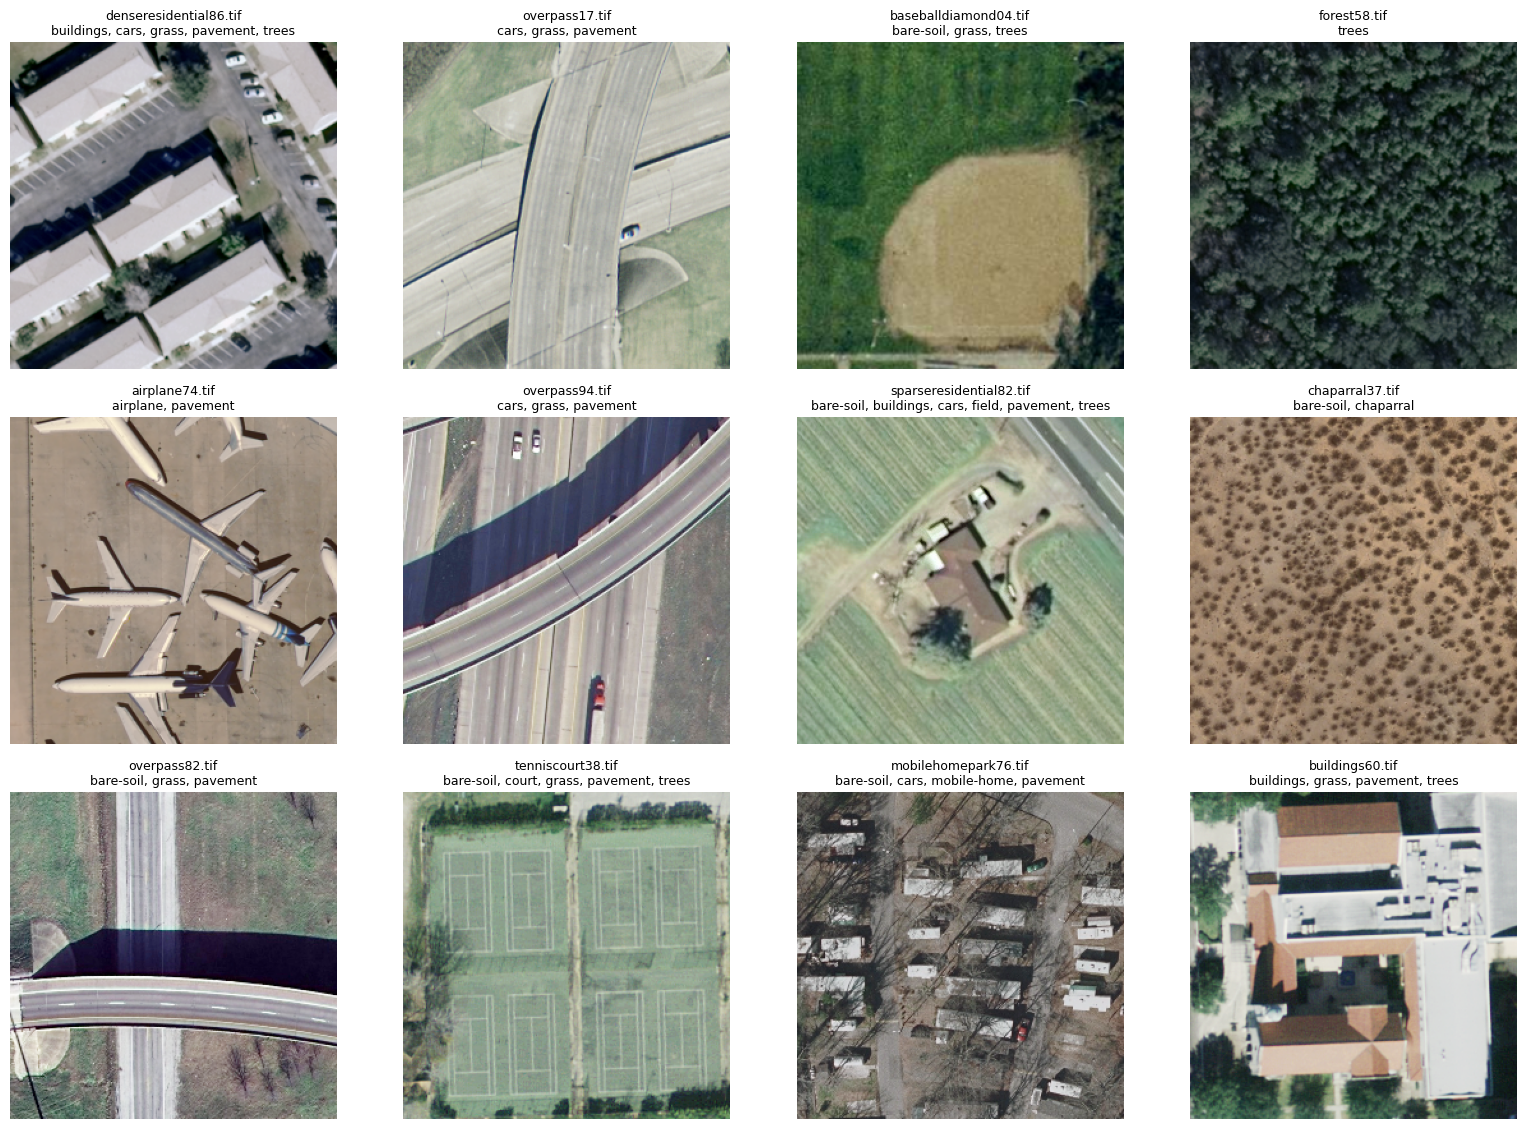

In [3]:
# Inspect dataset structure
image_files = sorted(
    [p for p in IMAGES_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}]
)
print(f"Found {len(image_files)} images in: {IMAGES_DIR}")
print("Image extensions:", pd.Series([p.suffix.lower() for p in image_files]).value_counts().to_dict())

with open(LABELS_FILE, "r", encoding="utf-8", errors="ignore") as f:
    raw_lines = [ln.strip() for ln in f if ln.strip()]

print(f"Found {len(raw_lines)} non-empty label lines in: {LABELS_FILE}")
print("Sample label lines:")
for s in raw_lines[:3]:
    print("  ", s)

# Parse labels file into a filename/stem -> label mapping
label_map = {}
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

for line in raw_lines:
    if "\t" in line:
        parts = [p.strip() for p in line.split("\t") if p.strip()]
    elif "," in line:
        parts = [p.strip() for p in line.split(",") if p.strip()]
    else:
        parts = line.split()

    if not parts:
        continue

    # Find token that looks like an image filename, otherwise use first token as ID
    img_token_idx = None
    for i, t in enumerate(parts):
        if Path(t).suffix.lower() in image_exts:
            img_token_idx = i
            break

    if img_token_idx is None:
        img_id = parts[0]
        label_tokens = parts[1:]
    else:
        img_id = parts[img_token_idx]
        label_tokens = parts[:img_token_idx] + parts[img_token_idx + 1 :]

    # Format labels for display
    # Initialize class names from the header once
    if "class_names" not in locals():
        header = raw_lines[0]
        if "\t" in header:
            header_parts = [p.strip() for p in header.split("\t") if p.strip()]
        elif "," in header:
            header_parts = [p.strip() for p in header.split(",") if p.strip()]
        else:
            header_parts = header.split()
        class_names = header_parts[1:] if header_parts and "image" in header_parts[0].lower() else []

    # Skip header row during parsing
    if str(img_id).upper().replace("/", "\\") == "IMAGE\\LABEL":
        continue

    # Convert binary multi-label vector to class names
    if label_tokens and all(tok in {"0", "1"} for tok in label_tokens) and len(class_names) == len(label_tokens):
        label_tokens = [class_names[i] for i, v in enumerate(label_tokens) if v == "1"]
    if label_tokens and all(tok in {"0", "1"} for tok in label_tokens):
        active = [str(i) for i, v in enumerate(label_tokens) if v == "1"]
        label_text = f"active class idx: {', '.join(active) if active else 'none'}"
    else:
        label_text = ", ".join(label_tokens) if label_tokens else "(no label text)"

    # Map by full name and stem for flexible matching
    label_map[img_id] = label_text
    label_map[Path(img_id).stem] = label_text

# Random sample and plot
n_plot = min(12, len(image_files))
sampled = random.sample(image_files, k=n_plot) if n_plot > 0 else []

cols = 4
rows = (n_plot + cols - 1) // cols if n_plot else 1
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.8 * rows))
axes = [axes] if rows == 1 and cols == 1 else axes.ravel()

for ax, img_path in zip(axes, sampled):
    img = plt.imread(img_path)
    label_text = label_map.get(img_path.name, label_map.get(img_path.stem, "label not found"))

    ax.imshow(img)
    ax.set_title(f"{img_path.name}\n{label_text}", fontsize=9)
    ax.axis("off")

for ax in axes[len(sampled):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Total images: 2100
Images with label entry in file: 2100
Images with at least 1 active label: 2100


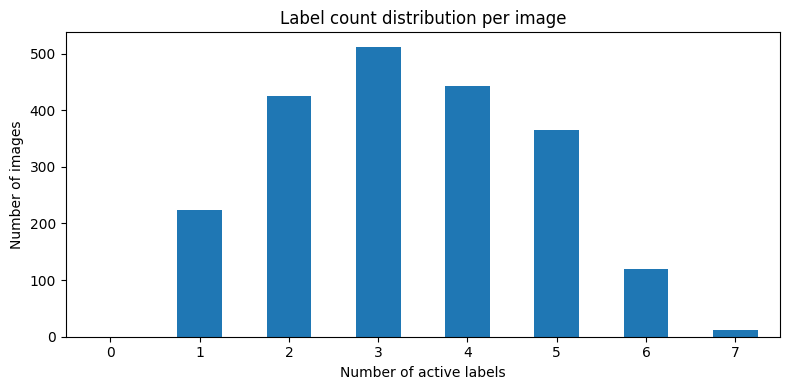

In [4]:
# Build image_id -> number of active labels from the label file
label_count_by_id = {}

for line in raw_lines[1:]:  # skip header
    if "\t" in line:
        parts = [p.strip() for p in line.split("\t") if p.strip()]
    elif "," in line:
        parts = [p.strip() for p in line.split(",") if p.strip()]
    else:
        parts = line.split()

    if not parts:
        continue

    img_id = Path(parts[0]).stem
    tokens = parts[1:]

    if tokens and all(t in {"0", "1"} for t in tokens):
        label_count_by_id[img_id] = sum(int(t) for t in tokens)

# Match label counts to discovered image files
image_label_counts = [label_count_by_id.get(p.stem, None) for p in image_files]

total_images = len(image_files)
images_with_label_entry = sum(c is not None for c in image_label_counts)
images_with_labels = sum((c is not None) and (c > 0) for c in image_label_counts)

print(f"Total images: {total_images}")
print(f"Images with label entry in file: {images_with_label_entry}")
print(f"Images with at least 1 active label: {images_with_labels}")

# Distribution: number of active labels per image (0 labels, 1 label, 2 labels, ...)
valid_counts = pd.Series([c for c in image_label_counts if c is not None], name="n_labels")
dist = valid_counts.value_counts().sort_index()

if not dist.empty:
    dist = dist.reindex(range(0, int(dist.index.max()) + 1), fill_value=0)

plt.figure(figsize=(8, 4))
dist.plot(kind="bar")
plt.title("Label count distribution per image")
plt.xlabel("Number of active labels")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

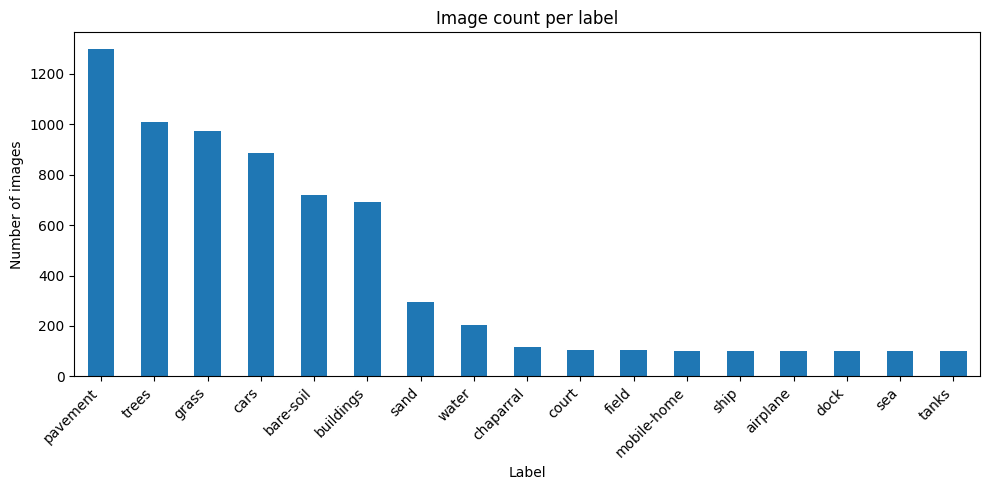

In [5]:
# Count how many images contain each label (active = 1)
rows = []
for line in raw_lines[1:]:  # skip header
    if "\t" in line:
        parts = [p.strip() for p in line.split("\t") if p.strip()]
    elif "," in line:
        parts = [p.strip() for p in line.split(",") if p.strip()]
    else:
        parts = line.split()

    tokens = parts[1:]
    if len(tokens) == len(class_names) and all(t in {"0", "1"} for t in tokens):
        rows.append([int(t) for t in tokens])

label_counts = pd.DataFrame(rows, columns=class_names).sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Image count per label")
plt.xlabel("Label")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# Print unique image dimensions and their counts
if "image_shape_count" not in locals():
    image_shape_count = {}
    for p in image_files:
        img = plt.imread(p)
        h, w = img.shape[:2]
        image_shape_count[(h, w)] = image_shape_count.get((h, w), 0) + 1

print(f"Unique dimensions: {len(image_shape_count)}")
for (h, w), count in sorted(image_shape_count.items(), key=lambda x: (x[0][0], x[0][1])):
    print(f"{h}x{w}: {count}")

Unique dimensions: 17
242x256: 1
247x247: 9
247x256: 1
249x256: 1
250x256: 2
252x256: 2
253x256: 6
254x256: 3
255x256: 4
256x247: 1
256x249: 2
256x251: 5
256x253: 3
256x254: 2
256x255: 1
256x256: 2056
257x257: 1
